In [1]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("../data/train_sample.csv")


In [2]:
# Check the dataset
print(df.info())
print(df.describe())
# Check the data of each column
print("\nData sample:\n", df.head())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1000 non-null   object 
 1   Customer_ID               1000 non-null   object 
 2   Month                     1000 non-null   object 
 3   Name                      902 non-null    object 
 4   Age                       1000 non-null   object 
 5   SSN                       1000 non-null   object 
 6   Occupation                1000 non-null   object 
 7   Annual_Income             1000 non-null   object 
 8   Monthly_Inhand_Salary     845 non-null    float64
 9   Num_Bank_Accounts         1000 non-null   int64  
 10  Num_Credit_Card           1000 non-null   int64  
 11  Interest_Rate             1000 non-null   int64  
 12  Num_of_Loan               1000 non-null   object 
 13  Type_of_Loan              832 non-null    object 
 14  Delay_fro

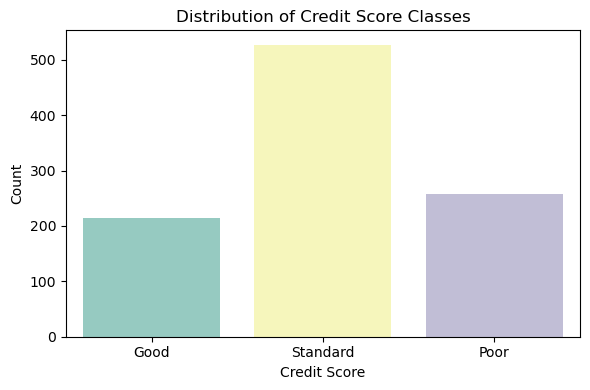

In [3]:
# EDA Visualize distributions of key features

# Distribution of target variable
#1 Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()# Explore feature distributions by Credit Score

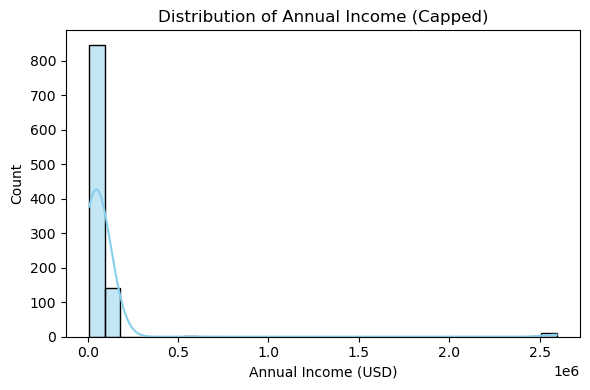

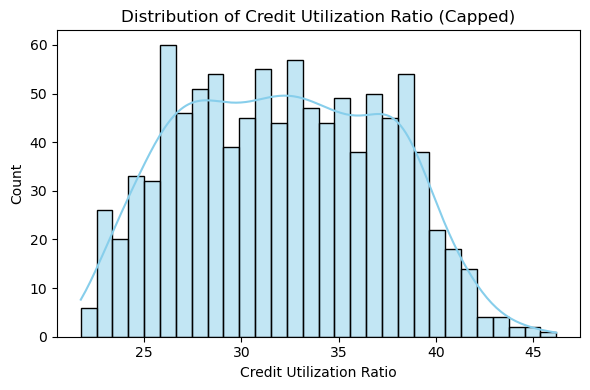

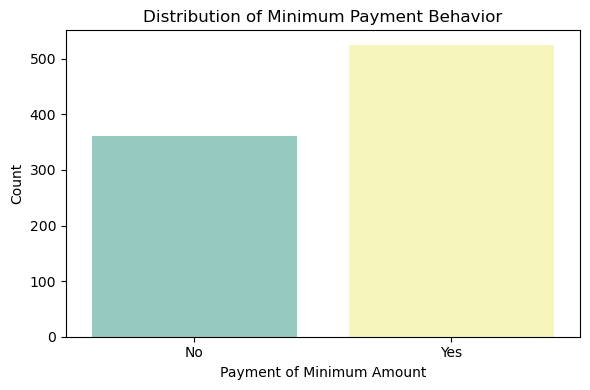

In [4]:
#Distributions of key features
# 1 Annual Income distribution
df_plot = df.copy()

df_plot["Annual_Income"] = (
    df_plot["Annual_Income"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("_", "", regex=False)
)

df_plot["Annual_Income"] = pd.to_numeric(df_plot["Annual_Income"], errors="coerce")

cap_value = df_plot["Annual_Income"].quantile(0.99)
df_plot["Annual_Income"] = np.minimum(df_plot["Annual_Income"], cap_value)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Annual_Income",
    kde=True,
    bins=30,
    color="skyblue"
)
plt.title("Distribution of Annual Income (Capped)")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2 Credit Utilization Ratio distribution
df_plot = df.copy()
df_plot["Credit_Utilization_Ratio"] = pd.to_numeric(df_plot["Credit_Utilization_Ratio"], errors="coerce")

cap = df_plot["Credit_Utilization_Ratio"]
df_plot["Credit_Utilization_Ratio"] = np.minimum(df_plot["Credit_Utilization_Ratio"], cap)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Credit_Utilization_Ratio",
    kde=True,
    bins=30,
    color="skyblue"
)
plt.title("Distribution of Credit Utilization Ratio (Capped)")
plt.xlabel("Credit Utilization Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3 Payment of Minimum Amount distribution
df_eda = df[df["Payment_of_Min_Amount"].isin(["Yes", "No"])]

plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x="Payment_of_Min_Amount", hue="Payment_of_Min_Amount", palette="Set3")
plt.title("Distribution of Minimum Payment Behavior")
plt.xlabel("Payment of Minimum Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

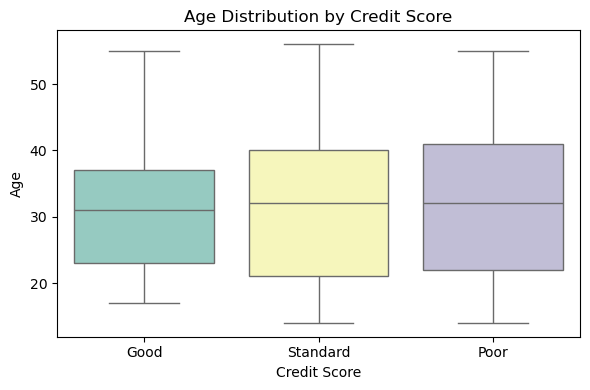

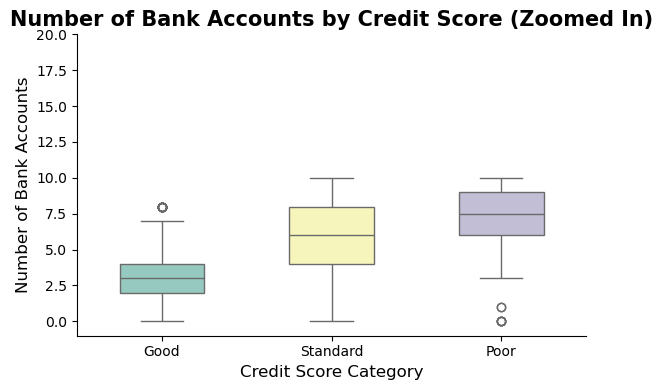

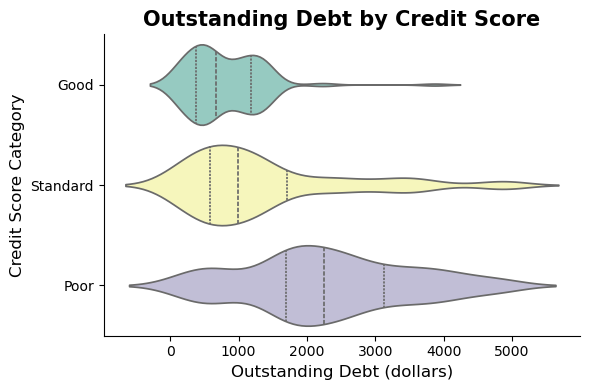

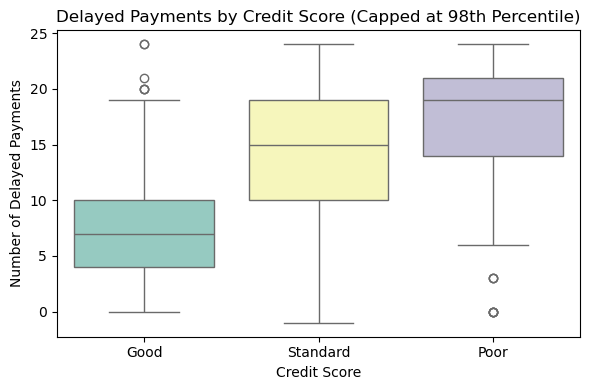

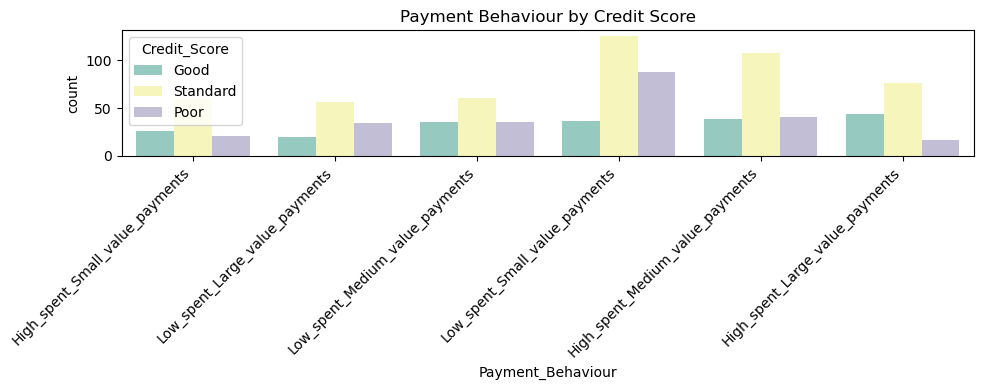

In [5]:
# Feature distributions by Credit Score
# 1 Age distribution by Credit Score
df_plot = df.copy()

df_plot["Age"] = pd.to_numeric(df_plot["Age"], errors="coerce")

df_plot = df_plot[(df_plot["Age"] > 0) & (df_plot["Age"] < 100)]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Age",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Age Distribution by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


# 2 Number of Bank Accounts distribution by Credit Score
df_plot = df.copy()
df_plot["Num_Bank_Accounts"] = pd.to_numeric(df_plot["Num_Bank_Accounts"], errors="coerce")
df_plot = df_plot[df_plot["Num_Bank_Accounts"] >= 0]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_Bank_Accounts",
    order=["Good","Standard","Poor"],
    palette="Set3",
    width=0.5
)

plt.title("Number of Bank Accounts by Credit Score (Zoomed In)", fontsize=15, weight='bold')
plt.xlabel("Credit Score Category", fontsize=12)
plt.ylabel("Number of Bank Accounts", fontsize=12)

plt.ylim(-1, 20)

sns.despine()
plt.tight_layout()
plt.show()


# 3 Outstanding Debt distribution by Credit Score
df_plot = df.copy()

df_plot["Outstanding_Debt"] = (
    df_plot["Outstanding_Debt"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace("NA", np.nan)
)

df_plot["Outstanding_Debt"] = pd.to_numeric(df_plot["Outstanding_Debt"], errors="coerce")

plt.figure(figsize=(6,4))
sns.violinplot(
    data=df_plot,
    y="Credit_Score",
    x="Outstanding_Debt",
    hue="Credit_Score",
    order=["Good","Standard","Poor"],
    palette="Set3",
    inner="quartile"
)

plt.title("Outstanding Debt by Credit Score", fontsize=15, weight='bold')
plt.xlabel("Outstanding Debt (dollars)", fontsize=12)
plt.ylabel("Credit Score Category", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# 4 Number of Delayed Payment distribution by Credit Score
df_plot = df.copy()
df_plot["Num_of_Delayed_Payment"] = pd.to_numeric(df_plot["Num_of_Delayed_Payment"], errors="coerce")

cap = df_plot["Num_of_Delayed_Payment"].quantile(0.98)
df_plot["Num_of_Delayed_Payment"] = np.minimum(df_plot["Num_of_Delayed_Payment"], cap)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_of_Delayed_Payment",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Delayed Payments by Credit Score (Capped at 98th Percentile)")
plt.xlabel("Credit Score")
plt.ylabel("Number of Delayed Payments")
plt.tight_layout()
plt.show()

# 5 Payment Behaviour distribution by Credit Score
df_plot = df[df["Payment_Behaviour"] != "!@9#%8"].copy()

plt.figure(figsize=(10,4))
sns.countplot(
    data=df_plot,
    x="Payment_Behaviour",
    hue="Credit_Score",
    palette="Set3"
)
plt.xticks(rotation=45, ha="right")
plt.title("Payment Behaviour by Credit Score")
plt.tight_layout()
plt.show()

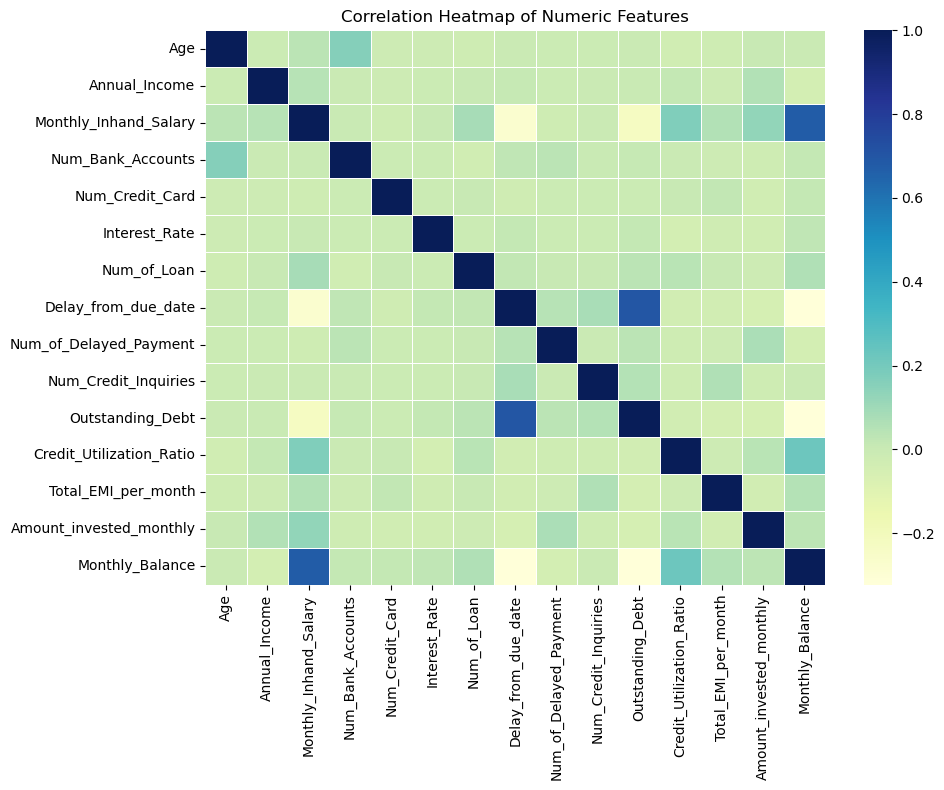

In [6]:
# Correlation heatmap

# Create cleaned numeric copy
df_corr = df.copy()

# Define candidate numeric columns (from your list)
numeric_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]


# Fix dtype issues
for col in numeric_cols:
    df_corr[col] = (
        df_corr[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("_", "", regex=False)
    )
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Handle invalid values
df_corr.loc[df_corr["Age"] < 0, "Age"] = np.nan
df_corr.loc[df_corr["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


In [7]:
# Data Cleaning
df_clean = df.copy()

def clean_numeric(s):
    return (
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("_", "", regex=False)
         .replace(["NA", "NM", "None", ""], np.nan)
    )

numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
]

for col in numeric_object_cols:
    df_clean[col] = clean_numeric(df_clean[col])
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Age impossible (<0 or >100)
df_clean = df_clean[(df_clean["Age"] > 0) & (df_clean["Age"] < 100)]

# Num_of_Loan cannot be negative
df_clean = df_clean[df_clean["Num_of_Loan"] >= 0]

# Num_of_Delayed_Payment cannot be negative
df_clean = df_clean[(df_clean["Num_of_Delayed_Payment"] >= 0)]

# Outstanding_Debt cannot be negative
df_clean = df_clean[(df_clean["Outstanding_Debt"] >= 0)]

# Credit_Utilization_Ratio cannot be negative or above 100
# (if >100 it's fraud but not impossible, so only drop <0 here)
df_clean = df_clean[df_clean["Credit_Utilization_Ratio"] >= 0]

# Delay_from_due_date cannot be negative
df_clean = df_clean[df_clean["Delay_from_due_date"] >= 0]

# Interest rate cannot exceed 100% in any real consumer loan scenario
df_clean = df_clean[df_clean["Interest_Rate"] <= 100]

# Monthly_Balance: remove thousand separators and cast to numeric
df_clean["Monthly_Balance"] = (
    df_clean["Monthly_Balance"]
    .astype(str)
    .str.replace(",", "")
)
df_clean["Monthly_Balance"] = pd.to_numeric(df_clean["Monthly_Balance"], errors="coerce")

# Parse Credit_History_Age: "XX Years and YY Months" -> total months
def parse_credit_age(x):
    if pd.isna(x):
        return np.nan
    parts = x.split(" ")
    years = int(parts[0])
    months = int(parts[3])
    return years * 12 + months

df_clean["Credit_History_Age"] = df_clean["Credit_History_Age"].apply(parse_credit_age)

print("Shape before cleaning:", df.shape)
print("Shape after cleaning :", df_clean.shape)
print(df_clean.info())
print(df_clean.head())
print(df_clean.describe())



Shape before cleaning: (1000, 28)
Shape after cleaning : (834, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 834 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        834 non-null    object 
 1   Customer_ID               834 non-null    object 
 2   Month                     834 non-null    object 
 3   Name                      754 non-null    object 
 4   Age                       834 non-null    int64  
 5   SSN                       834 non-null    object 
 6   Occupation                834 non-null    object 
 7   Annual_Income             834 non-null    float64
 8   Monthly_Inhand_Salary     709 non-null    float64
 9   Num_Bank_Accounts         834 non-null    int64  
 10  Num_Credit_Card           834 non-null    int64  
 11  Interest_Rate             834 non-null    int64  
 12  Num_of_Loan               834 non-null    int64  
 13  Typ

In [8]:
# Check whether the dataset satisfies I.I.D. assumptions before dropping non-predictive ID columns

# 1. Each Customer_ID should map to only one SSN
cid_ssn_conflict = df_clean.groupby("Customer_ID")["SSN"].transform("nunique") > 1

# 2. Each Customer_ID should map to only one Name
cid_name_conflict = df_clean.groupby("Customer_ID")["Name"].transform("nunique") > 1

# 3. Each SSN should map to only one Customer_ID
ssn_cid_conflict = df_clean.groupby("SSN")["Customer_ID"].transform("nunique") > 1

# 4. Each SSN should map to only one Name
ssn_name_conflict = df_clean.groupby("SSN")["Name"].transform("nunique") > 1

# 5. ID should be unique, but check for safety
id_conflict = df_clean["ID"].duplicated(keep=False)

# Combine all conflict conditions
conflict_mask = (
    cid_ssn_conflict |
    cid_name_conflict |
    ssn_cid_conflict |
    ssn_name_conflict |
    id_conflict
)
# The misaligned rows (PS: NOT dropping them)
conflict_rows = df_clean[conflict_mask]
print("misaligned rows:",(conflict_rows.head(10)))

# Count unique valid person SSNs
persons = df_clean["SSN"].value_counts()
print("Number of unique persons:", len(persons))
print(persons.head())

"""Although each individual has 8 monthly records, this dataset is not treated as a classical time series problem. In a true time series task, the target at time t depends strictly on past values (e.g., ARIMA, forecasting). Here, the goal is classification of credit score, using all available features at each month. The temporal order does not define the predictive structure, and the target is not modeled as a sequence. Therefore, the dataset is best interpreted as panel data (repeated cross-sections) rather than a forecasting problem."""

# Drop non-predictive non-grouping columns
df_clean = df_clean.drop(columns=["Customer_ID", "Name", "ID"])

"""According to entity-resolution literature (Christen 2012; Wooldridge 2010), such inconsistencies in identity attributes are common in real-world and synthetic datasets and should not be used as a criterion for dropping observations, unless full entity resolution is performed.

Since the goal of this project is credit-score prediction—not identity reconciliation—these conflicts are treated as noisy metadata rather than erroneous samples. Dropping these rows would arbitrarily remove valid monthly observations and distort the distribution of the data.
"""

misaligned rows:         ID Customer_ID     Month           Name  Age          SSN  \
0   0x1602   CUS_0xd40   January  Aaron Maashoh   23  821-00-0265   
3   0x1605   CUS_0xd40     April  Aaron Maashoh   23  821-00-0265   
5   0x1607   CUS_0xd40      June  Aaron Maashoh   23  821-00-0265   
6   0x1608   CUS_0xd40      July  Aaron Maashoh   23  821-00-0265   
7   0x1609   CUS_0xd40    August            NaN   23    #F%$D@*&8   
24  0x1626  CUS_0xb891   January         Jasond   54  072-31-6145   
25  0x1627  CUS_0xb891  February         Jasond   54  072-31-6145   
26  0x1628  CUS_0xb891     March         Jasond   55  072-31-6145   
27  0x1629  CUS_0xb891     April         Jasond   55  072-31-6145   
28  0x162a  CUS_0xb891       May         Jasond   55  072-31-6145   

      Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
0      Scientist       19114.12            1824.843333                  3   
3      Scientist       19114.12                    NaN               

'According to entity-resolution literature (Christen 2012; Wooldridge 2010), such inconsistencies in identity attributes are common in real-world and synthetic datasets and should not be used as a criterion for dropping observations, unless full entity resolution is performed.\n\nSince the goal of this project is credit-score prediction—not identity reconciliation—these conflicts are treated as noisy metadata rather than erroneous samples. Dropping these rows would arbitrarily remove valid monthly observations and distort the distribution of the data.\n'

In [9]:
# Check missing values for each column which are not written as NA
for col in df_clean.columns:
    uniques = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(uniques)}")
    # Only print first 20 to avoid flooding
    print(uniques[:20])


--- Month ---
Unique count: 8
['January' 'April' 'June' 'July' 'August' 'February' 'May' 'March']

--- Age ---
Unique count: 39
[23 28 34 54 55 21 31 33 30 24 44 40 41 35 36 39 37 20 45 46]

--- SSN ---
Unique count: 126
['821-00-0265' '#F%$D@*&8' '004-07-5839' '486-85-3974' '072-31-6145'
 '615-06-7821' '612-70-8987' '411-51-0676' '500-92-6408' '070-19-1622'
 '366-68-1681' '221-30-8554' '342-90-2649' '414-53-2918' '328-33-6328'
 '655-05-7666' '965-46-2491' '891-55-9364' '928-91-4452' '084-25-3745']

--- Occupation ---
Unique count: 16
['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']

--- Annual_Income ---
Unique count: 136
[1.9114120e+04 3.4847840e+04 1.4316264e+05 3.0689890e+04 3.5547710e+04
 7.3928460e+04 1.3131340e+05 1.0909427e+07 3.4081380e+04 1.1483841e+05
 3.1370800e+04 3.3751270e+04 8.8640240e+04 5.4392160e+04 8.7015450e+03
 2.5546260e+04 3.

In [10]:
# Handle special missing value tokens in categorical columns
missing_tokens = ["_", "_______", "!@9#%8", "NM"]

for col in ["Occupation", "Credit_Mix", "Payment_Behaviour", "Payment_of_Min_Amount"]:
    df_clean[col] = df_clean[col].replace(missing_tokens, np.nan)

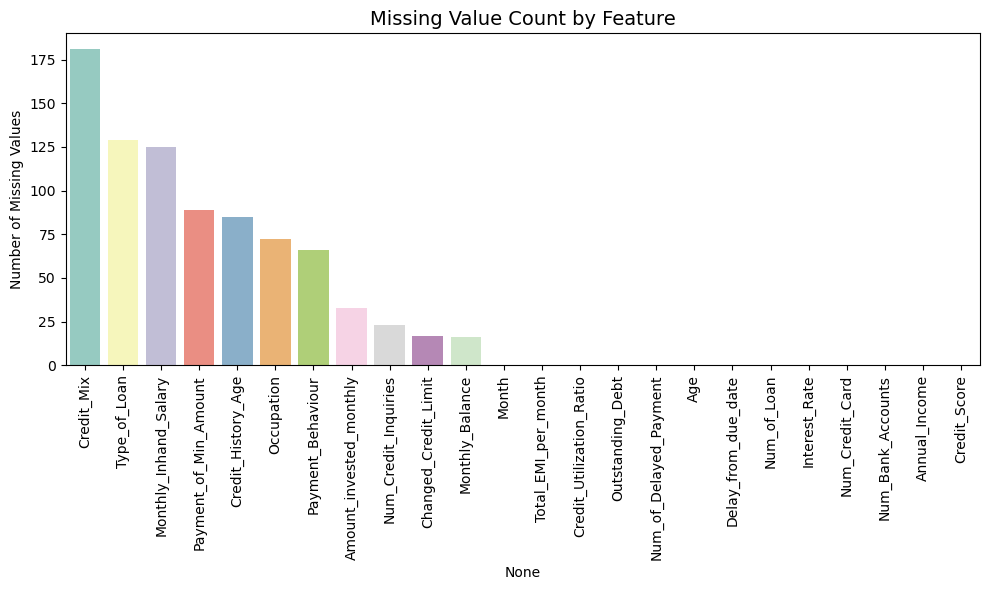

In [11]:
# Re-run the EDA visualizations on clean_df as needed
# Missing values per column in clean_df
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)

# Columns to exclude
exclude_cols = ["SSN"]

# Remove excluded columns
missing_counts = missing_counts.drop(labels=[c for c in exclude_cols if c in missing_counts.index])

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values,
    hue=missing_counts.index,
    palette="Set3"
)
plt.title("Missing Value Count by Feature", fontsize=14)
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

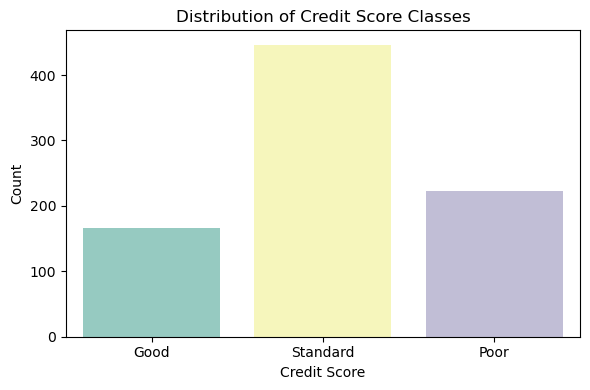

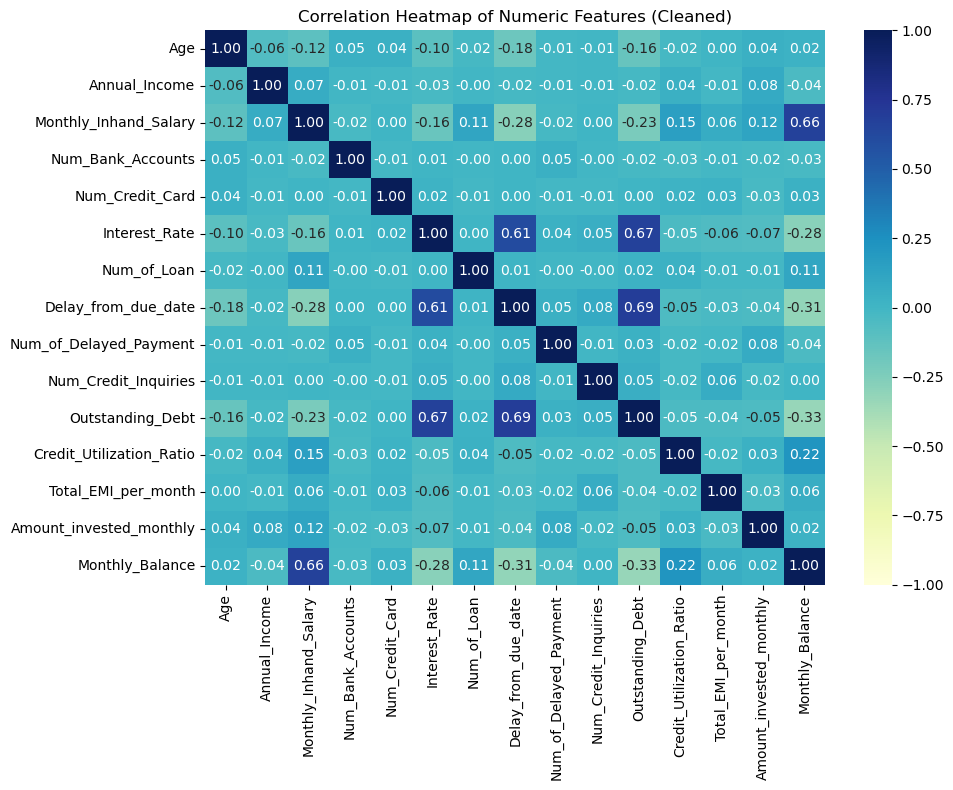

<class 'pandas.core.frame.DataFrame'>
Index: 834 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     834 non-null    object 
 1   Age                       834 non-null    int64  
 2   SSN                       834 non-null    object 
 3   Occupation                762 non-null    object 
 4   Annual_Income             834 non-null    float64
 5   Monthly_Inhand_Salary     709 non-null    float64
 6   Num_Bank_Accounts         834 non-null    int64  
 7   Num_Credit_Card           834 non-null    int64  
 8   Interest_Rate             834 non-null    int64  
 9   Num_of_Loan               834 non-null    int64  
 10  Type_of_Loan              705 non-null    object 
 11  Delay_from_due_date       834 non-null    int64  
 12  Num_of_Delayed_Payment    834 non-null    float64
 13  Changed_Credit_Limit      817 non-null    float64
 14  Num_Credit_Inqu

In [12]:
# Re-run some of the previous EDA plots on clean_df if needed
# The distribution of Credit_Score after cleaning
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Heatmap of correlations in clean_df
numeric_cols = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
    "Num_of_Delayed_Payment", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="YlGnBu",
    vmin=-1, vmax=1,      
    annot=True, fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features (Cleaned)")
plt.tight_layout()
plt.show()

print(df_clean.info())
for col in df_clean.columns:
    uniques = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(uniques)}")
    # Only print first 20 to avoid flooding
    print(uniques[:20])

In [13]:
# Type of loan is nested categorical, so we will manually encode it  
# Fill missing with "Missing"
df_clean["Type_of_Loan"] = df_clean["Type_of_Loan"].fillna("Missing")

# Extract unique loan types
def split_loan(text):
    text = str(text).replace("and", "").replace("  ", " ")
    parts = [p.strip() for p in text.split(",") if p.strip() != ""]
    return parts if parts else ["Missing"]

unique_loans = set()
for row in df_clean["Type_of_Loan"]:
    for item in split_loan(row):
        unique_loans.add(item)

unique_loans = sorted(list(unique_loans))
print("Loan types found:", unique_loans)

# Create binary columns for each loan type and drop original column
for loan in unique_loans:
    df_clean[f"Loan_{loan}"] = df_clean["Type_of_Loan"].apply(
        lambda x: 1 if loan in split_loan(x) else 0
    )
df_clean = df_clean.drop(columns=["Type_of_Loan"])

# Data Splitting and Preprocessing
X = df_clean.drop(columns="Credit_Score")
y = df_clean["Credit_Score"]
groups = df_clean["SSN"]

# GroupShuffleSplit
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups))

X_train_val = X.iloc[train_val_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
y_test  = y.iloc[test_idx].copy()

X_test  = X_test.drop(columns=["SSN"])

# Store the test set for final evaluation later
test_set = X_test.copy()
test_set["Credit_Score"] = y_test.values

test_set.to_csv("../data/test.csv", index=False)
print("Saved to data/test.csv")

Loan types found: ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Missing', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']
Saved to data/test.csv


In [15]:
# Preprocessing pipeline (Handle missing values, categorical encoding, scaling, etc.)
# Build the column transformer
from sklearn.experimental import enable_iterative_imputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify ordinal and categorical columns

ordinal_cols = ["Credit_Mix", "Payment_of_Min_Amount"]
Credit_Mix_order = ["Missing", "Bad", "Standard", "Good"]
Payment_of_Min_Amount_order = ["Missing", "Yes", "No"]

categorical_cols = ["Month", "Occupation", "Payment_Behaviour"]

numeric_cols = ["Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt", "Credit_Utilization_Ratio","Credit_History_Age", "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OrdinalEncoder(categories=[Credit_Mix_order, Payment_of_Min_Amount_order]))
])

numeric_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("num", numeric_pipeline, numeric_cols)
    ]
)

i = 0
full_preprocess = Pipeline([
    ("prep", preprocess),
    ("impute", IterativeImputer(random_state=i)),
    ("scale", StandardScaler())
])

# Define a K-fold cross-validation scheme
from sklearn.model_selection import GroupKFold

groups = X_train_val["SSN"]
X_train_val = X_train_val.drop(columns=["SSN"])

gkf = GroupKFold(n_splits=5)


In [16]:
# Hyperparameter tunning  for Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_scores = []

# Put model in a pipeline with preprocessing
for i in range(5):
    print(f"Round {i+1}: ")
    logreg_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", LogisticRegression(
            solver="saga",
            penalty="l2",
            max_iter=8000,
            n_jobs=-1
        ))
    ])

    # Define hyperparameter grid
    param_grid_logreg = {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    }

    # Set up GridSearchCV
    logreg_grid = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=param_grid_logreg,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    logreg_grid.fit(X_train_val, y_train_val, groups=groups)
    
    logreg_scores.append(logreg_grid.best_score_)
    
    print("Best params:", logreg_grid.best_params_)
    print("Best CV score:", logreg_grid.best_score_)

Round 1: 
Best params: {'model__C': 0.1}
Best CV score: 0.565426824513238
Round 2: 
Best params: {'model__C': 0.1}
Best CV score: 0.565426824513238
Round 3: 
Best params: {'model__C': 0.1}
Best CV score: 0.565426824513238
Round 4: 
Best params: {'model__C': 0.1}
Best CV score: 0.565426824513238
Round 5: 
Best params: {'model__C': 0.1}
Best CV score: 0.565426824513238


In [ ]:
#Hyperparameter tuning for Linear SVM (LinearSVC)
from sklearn.linear_model import SGDClassifier

linear_svc_scores = []

for i in range():
    print(f"\nRound {i+1}: ")

    svc_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", SGDClassifier(
            loss="hinge",
            penalty="l2",
            max_iter=2000,
            n_jobs=-1,
            tol=1e-3
        ))
    ])
    
    param_grid_svc = {
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    }

    svc_grid = GridSearchCV(
        estimator=svc_pipeline,
        param_grid=param_grid_svc,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    svc_grid.fit(X_train_val, y_train_val, groups=groups)

    linear_svc_scores.append(svc_grid.best_score_)

    print("Best params:", svc_grid.best_params_)
    print("Best CV score:", svc_grid.best_score_)



Round 1: 
Best params: {'model__alpha': 1e-05}
Best CV score: 0.5260185334757543

Round 2: 
Best params: {'model__alpha': 1e-05}
Best CV score: 0.4990849641196961

Round 3: 
Best params: {'model__alpha': 1e-05}
Best CV score: 0.511894344237182

Round 4: 
Best params: {'model__alpha': 1e-05}
Best CV score: 0.5144725899146992

Round 5: 
Best params: {'model__alpha': 1e-05}
Best CV score: 0.49487426310329663


In [17]:
# Hyperparameter tuning for RBF SVM (SVC) NON-LINEAR
from sklearn.svm import SVC

svc_rbf_scores = []

for i in range(5):
    print(f"\nRound {i+1}:")
    
    # Build pipeline
    svc_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", SVC(
            kernel="rbf",
            probability=False,
        ))
    ])

    # Hyperparameter grid
    param_grid_svc = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": [0.001, 0.01, 0.1, 1, 10],
    }

    # GridSearchCV with GroupKFold
    svc_grid = GridSearchCV(
        estimator=svc_pipeline,
        param_grid=param_grid_svc,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    svc_grid.fit(X_train_val, y_train_val, groups=groups)

    svc_rbf_scores.append(svc_grid.best_score_)

    print("Best params:", svc_grid.best_params_)
    print("Best CV score:", svc_grid.best_score_)



Round 1:
Best params: {'model__C': 10, 'model__gamma': 0.001}
Best CV score: 0.5639137856867824

Round 2:
Best params: {'model__C': 10, 'model__gamma': 0.001}
Best CV score: 0.5639137856867824

Round 3:
Best params: {'model__C': 10, 'model__gamma': 0.001}
Best CV score: 0.5639137856867824

Round 4:
Best params: {'model__C': 10, 'model__gamma': 0.001}
Best CV score: 0.5639137856867824

Round 5:
Best params: {'model__C': 10, 'model__gamma': 0.001}
Best CV score: 0.5639137856867824


In [18]:
# Hyperparameter tuning for KNN
from sklearn.neighbors import KNeighborsClassifier

knn_scores = []

for i in range(5):
    print(f"\nRound {i+1}:")
    
    knn_pipeline = Pipeline([
        ("prep", full_preprocess), 
        ("model", KNeighborsClassifier())
    ])

    param_grid_knn = {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    }

    # GridSearchCV with GroupKFold
    knn_grid = GridSearchCV(
        estimator=knn_pipeline,
        param_grid=param_grid_knn,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    knn_grid.fit(X_train_val, y_train_val, groups=groups)

    knn_scores.append(knn_grid.best_score_)

    print("Best params:", knn_grid.best_params_)
    print("Best CV score:", knn_grid.best_score_)



Round 1:
Best params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV score: 0.5640548193266192

Round 2:
Best params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV score: 0.5640548193266192

Round 3:
Best params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV score: 0.5640548193266192

Round 4:
Best params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV score: 0.5640548193266192

Round 5:
Best params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV score: 0.5640548193266192


In [21]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le_y = LabelEncoder()
y_train_val_enc = le_y.fit_transform(y_train_val)

categorical_cols = ["Month", "Occupation", "Payment_Behaviour"]
ordinal_cols = ["Credit_Mix", "Payment_of_Min_Amount"]

Credit_Mix_order = ["Bad", "Standard", "Good"]
Payment_of_Min_Amount_order = ["Yes", "No"]

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

xgb_preprocess = ColumnTransformer(
    transformers=[
        # categorical: encode but preserve NaN
    ("cat", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=np.nan,        # unseen categories → NaN
        encoded_missing_value=np.nan # existing NaN → keep NaN
    ), categorical_cols),

        # ordinal: encode with your real order, NaN preserved
    ("ord", OrdinalEncoder(
        categories=[Credit_Mix_order, Payment_of_Min_Amount_order],
        handle_unknown="use_encoded_value",
        unknown_value=np.nan,
        encoded_missing_value=np.nan
    ), ordinal_cols),

        ("num", "passthrough", numeric_cols),  
        ("loan", "passthrough",
             [col for col in X_train_val.columns if col.startswith("Loan_")]), 
    ],
    remainder="drop"
)

import xgboost as xgb
from sklearn.pipeline import Pipeline

pipeline_xgboost = Pipeline([
    ("prep", xgb_preprocess),
    ("model", xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        random_state=0,
        tree_method="exact"
    ))
])

param_grid_xgb = {
        "model__max_depth": [3, 5, 7, 9, 11],
        "model__learning_rate": [0.005,0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=pipeline_xgboost,
    param_grid=param_grid_xgb,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)
xgb_grid.fit(X_train_val, y_train_val_enc, groups=groups)

print("Best params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)

Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__subsample': 0.8}
Best CV score: 0.6503955848184599


Exception ignored in: <function ResourceTracker.__del__ at 0x102955bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1038d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1066e9bc0>
Traceback (most recent call last

In [ ]:
# Hyperparameter tuning for Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_scores = []

for i in range(5):
    print(f"\nRound {i+1}:")
    
    # Build pipeline
    rf_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ])

    # Hyperparameter grid
    param_grid_rf = {
        "model__n_estimators": [200, 400, 500],
        "model__max_depth": [3, 5, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt"],
    }


    # GridSearchCV with GroupKFold
    rf_grid = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=param_grid_rf,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    rf_grid.fit(X_train_val, y_train_val, groups=groups)

    rf_scores.append(rf_grid.best_score_)

    print("Best params:", rf_grid.best_params_)
    print("Best CV score:", rf_grid.best_score_)



Round 1:
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV score: 0.6687755090148533

Round 2:
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV score: 0.6687755090148533

Round 3:
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV score: 0.6687755090148533

Round 4:
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV score: 0.6687755090148533

Round 5:
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV score: 0.6687755

Exception ignored in: <function ResourceTracker.__del__ at 0x104815bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1032c5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10723dbc0>
Traceback (most recent call last